## Simulating a lock complex with two lock chambers on the same edge
In this notebook, we simulate a lock on a simple one-route graph which randomly generated vessels have to pass. We add a lock complex object on the graph, which has two lock chambers: a small one and a large one. The lock chambers are located next to each other, and we simplify this by saying that the lock chambers are on top of each other. Vessels are locked together if they can fit inside the lock and register themselves before the start of the operation.

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# import of basic core mixins and utils for creating objects, inspecting the output and plotting
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.utils import create_object, generate_vessels_from_distribution
from opentnsim.core.visualizations import generate_vessel_gantt_chart

# import of utils for graph visualization
from opentnsim.graph.visualizations import plot_graph

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable

# package(s) needed for inspecting the output
import pandas as pd

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 2.2.2.dev109+g3ac0a4244.d20260416


#### 0. Create environment

In [2]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

#### 1. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('-1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','-1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('0','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('1','+1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('+1','1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

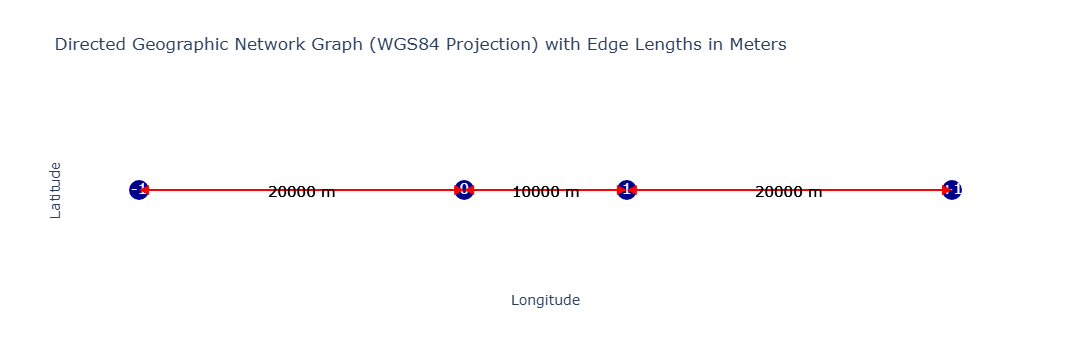

In [4]:
plot_graph(graph)

#### 1+ Adding infrastructure
We add two lock chambers with different dimensions:

In [5]:
lock_chamber_I = IsLockChamber(env=env,
                               lock_depth = 6,
                               name='Lock chamber I',
                               gate_open = '0',
                               edge = ('0','1'),
                               geometry_m = Polygon([Point(-150, -20),Point(-150, 20),Point(150, 20),Point(150, -20)]))

lock_chamber_II = IsLockChamber(env=env,
                                lock_depth = 6,
                                name='Lock chamber II',
                                gate_open = '0',
                                edge = ('0','1'),
                                geometry_m = Polygon([Point(-75, -10),Point(-75, 10),Point(75, 10),Point(75, -10)]))

But we keep the two waiting areas, which are then used by all the vessels that have to pass the lock complex.

In [6]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('0','1'),
                                   orientation = 0,
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('1','0'),
                                   orientation = 1,
                                   distance_from_edge_start = 0)

We add the infrastructure to the complex as follows:

In [7]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber_I, lock_chamber_II],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['0','1'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
We again generate upstream and downstream vessel agents according to exponential distributions.

In [8]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
    ), 
)

In [9]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [10]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':135, 'B':17, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=30.,
                                                      number_of_vessels=8,
                                                      start_node = '-1',
                                                      end_node = '+1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':135, 'B':17, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=30.,
                                                        number_of_vessels=8,
                                                        start_node = '+1',
                                                        end_node = '-1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation

In [11]:
env.run()

In [12]:
lock_complex.operation_planning

,node_from,node_to,direction,lock_chamber,operation_index,vessels,capacity_L,capacity_B,time_potential_lock_gate_opening_stop,time_lock_operation_start,...,time_gate_opening_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_operation_stop,time_potential_lock_gate_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
0,0,1,0,Lock chamber I,0,[],300.0,40.0,2025-01-01 01:38:04.354414,2025-01-01 01:38:04.354414,...,2025-01-01 01:58:04.354414,2025-01-01 01:58:04.354414,2025-01-01 01:58:04.354414,2025-01-01 01:58:04.354414,2025-01-01 01:58:04.354414,NaN,NaN,NaN,NaN,NaN
1,1,0,1,Lock chamber I,1,[<opentnsim.core.utils.Vessel object at 0x0000...,30.0,40.0,2025-01-01 01:49:36.854414,2025-01-01 01:58:04.354414,...,2025-01-01 02:32:28.422958088,2025-01-01 02:32:28.422958088,2025-01-01 02:36:34.027709764,2025-01-01 02:38:06.527709764,2025-01-01 02:38:34.027709764,NaN,NaN,NaN,NaN,processed
2,0,1,0,Lock chamber II,0,[<opentnsim.core.utils.Vessel object at 0x0000...,15.0,20.0,2025-01-01 01:51:45.800491,2025-01-01 02:00:13.300491,...,2025-01-01 02:23:05.984076382,2025-01-01 02:23:05.984076382,2025-01-01 02:24:11.588828058,2025-01-01 02:25:44.088828058,2025-01-01 02:26:11.588828058,NaN,NaN,NaN,NaN,processed
3,0,1,0,Lock chamber I,2,[<opentnsim.core.utils.Vessel object at 0x0000...,30.0,40.0,2025-01-01 02:29:39.027710117,2025-01-01 02:38:06.527710117,...,2025-01-01 03:04:13.790129205,2025-01-01 03:04:13.790129205,2025-01-01 03:08:19.394880881,2025-01-01 03:09:51.894880881,2025-01-01 03:10:19.394880881,NaN,NaN,NaT,NaT,processed
4,1,0,1,Lock chamber II,1,[<opentnsim.core.utils.Vessel object at 0x0000...,15.0,20.0,2025-01-01 02:17:16.588828058,2025-01-01 02:25:44.088828058,...,2025-01-01 02:48:36.772413440,2025-01-01 02:48:36.772413440,2025-01-01 02:49:42.377165116,2025-01-01 02:51:14.877165116,2025-01-01 02:51:42.377165116,NaN,NaN,NaN,NaN,processed
5,0,1,0,Lock chamber II,2,[<opentnsim.core.utils.Vessel object at 0x0000...,15.0,20.0,2025-01-01 02:42:47.377165116,2025-01-01 02:51:14.877165116,...,2025-01-01 03:14:07.560750498,2025-01-01 03:14:07.560750498,2025-01-01 03:15:13.165502174,2025-01-01 03:16:45.665502174,2025-01-01 03:17:13.165502174,NaN,NaN,NaN,NaN,processed
6,1,0,1,Lock chamber I,3,[<opentnsim.core.utils.Vessel object at 0x0000...,165.0,40.0,2025-01-01 03:01:24.394880881,2025-01-01 03:09:51.894880881,...,2025-01-01 03:35:10.366803322,2025-01-01 03:35:10.366803322,2025-01-01 03:36:15.971554998,2025-01-01 03:37:48.471554998,2025-01-01 03:38:15.971554998,NaN,NaN,NaN,NaN,processed
7,0,1,0,Lock chamber I,4,[<opentnsim.core.utils.Vessel object at 0x0000...,30.0,40.0,2025-01-01 03:29:20.971554881,2025-01-01 03:37:48.471554881,...,2025-01-01 04:03:55.733973969,2025-01-01 04:03:55.733973969,2025-01-01 04:08:01.338725645,2025-01-01 04:09:33.838725645,2025-01-01 04:10:01.338725645,NaN,NaN,NaT,NaT,processed
8,1,0,1,Lock chamber II,3,[<opentnsim.core.utils.Vessel object at 0x0000...,15.0,20.0,2025-01-01 03:40:58.593527,2025-01-01 03:49:26.093527,...,2025-01-01 04:12:18.777112382,2025-01-01 04:12:18.777112382,2025-01-01 04:13:24.381864058,2025-01-01 04:14:56.881864058,2025-01-01 04:15:24.381864058,NaN,NaN,NaN,NaN,processed
9,1,0,1,Lock chamber I,5,[<opentnsim.core.utils.Vessel object at 0x0000...,30.0,40.0,2025-01-01 04:01:06.338725645,2025-01-01 04:09:33.838725645,...,2025-01-01 04:35:41.101144733,2025-01-01 04:35:41.101144733,2025-01-01 04:39:46.705896409,2025-01-01 04:41:19.205896409,2025-01-01 04:41:46.705896409,NaN,NaN,NaN,NaN,processed


#### 4. Inspect output

##### Gantt chart of event table
We can create a gantt chart of all the objects:

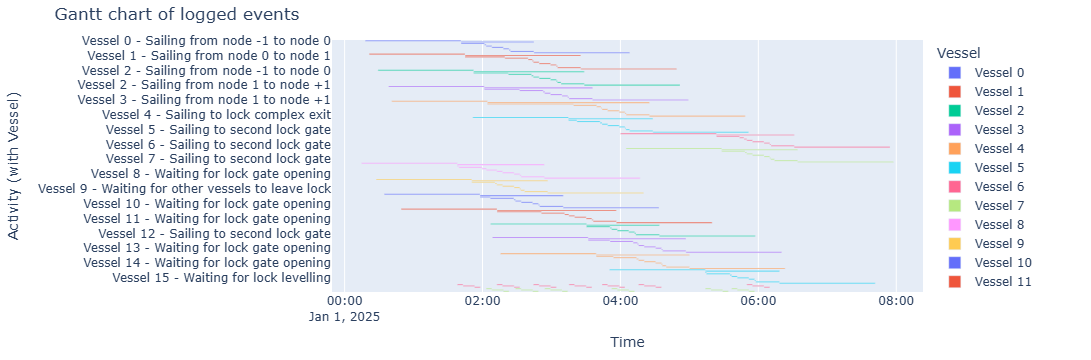

In [13]:
df_eventtable = logbook2eventtable([*vessels, lock_chamber_I, lock_chamber_II])
fig = generate_vessel_gantt_chart(df_eventtable)

##### Time-distance diagram of vessels passing the lock and planning info
And we can create time-distance diagrams for both locks. We observe that there are lock operations with two vessels for the larger lock, while there are lock operations with only one vessel for the smaller lock. The scheduling of the vessels followed a first-come, first-served approach, with the selected lock chamber being the one that would cause the least expected delay to any individual vessel.

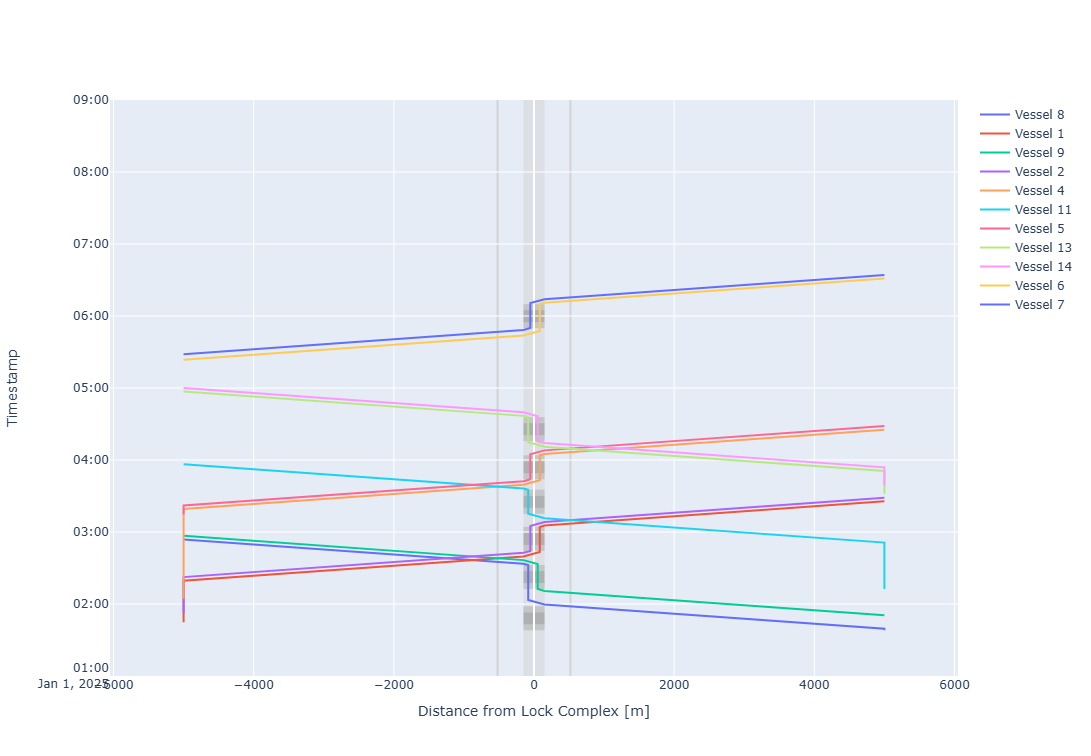

In [14]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber_I.plot(xlimmin = -6050, 
                          xlimmax = 6050,
                          ylimmin = pd.Timestamp('2025-01-01 01:00:00'),
                          ylimmax = pd.Timestamp('2025-01-01 09:00:00'),
                          method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

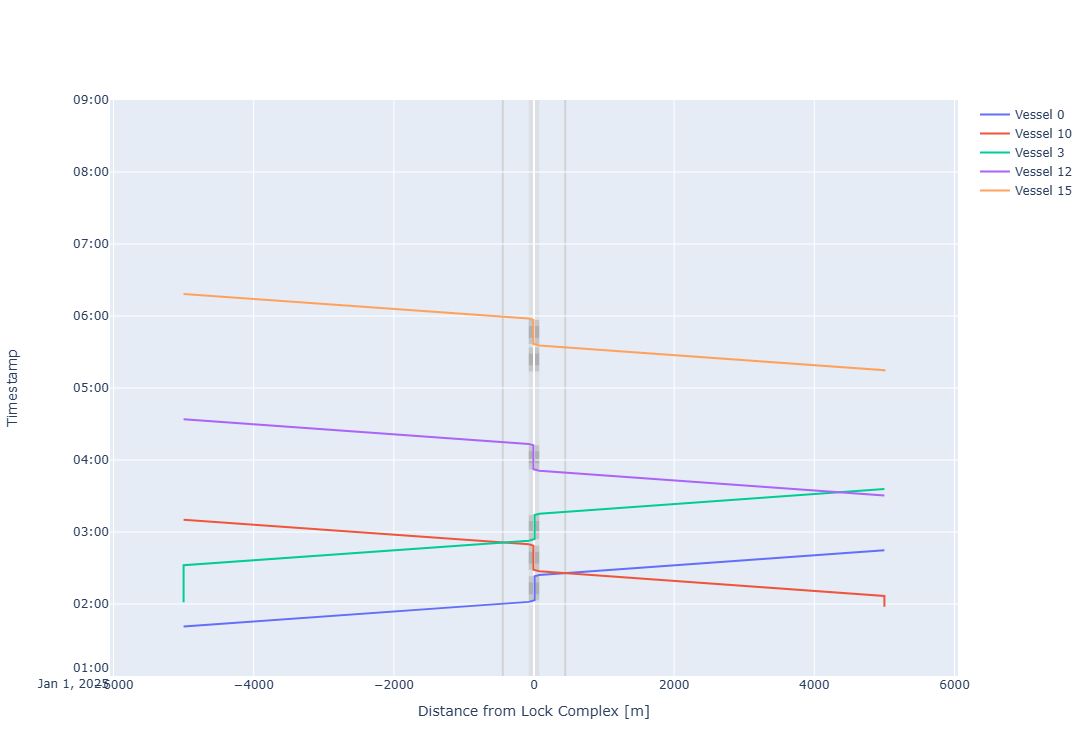

In [15]:
# We can plot the time-distance diagram
fig = lock_chamber_II.plot(xlimmin = -6050, 
                           xlimmax = 6050,
                           ylimmin = pd.Timestamp('2025-01-01 01:00:00'),
                           ylimmax = pd.Timestamp('2025-01-01 09:00:00'),
                           method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

In [16]:
pd.DataFrame(vessels[10].logbook)

,Message,Timestamp,Value,Geometry
0,Sailing from node +1 to node 1 start,2025-01-01 00:34:27.065476,0.0,POINT (0.2245788210298804 0)
1,Sailing from node +1 to node 1 stop,2025-01-01 01:57:47.065476,20000.0,POINT (0.0449157642059761 0)
2,Sailing from node 1 to node 0 start,2025-01-01 01:57:47.065476,20000.0,POINT (0.0449157642059761 0)
3,Waiting for lock operation start,2025-01-01 01:57:47.065476,20000.0,POINT (0.0449157642059761 0)
4,Waiting for lock operation stop,2025-01-01 02:06:45.338828,20000.0,POINT (0.0449157642059761 0)
5,Sailing to first lock gate start,2025-01-01 02:06:45.338828,20000.0,POINT (0.0449157642059761 0)
6,Sailing to first lock gate stop,2025-01-01 02:27:16.588828,24925.0,POINT (0.0006737364630896 0)
7,Sailing to position in lock start,2025-01-01 02:27:16.588828,24925.0,POINT (0.0006737364630896 0)
8,Sailing to position in lock stop,2025-01-01 02:28:36.772413,25007.5,POINT (-6.737364630898045e-5 0)
9,Waiting for lock gate closing start,2025-01-01 02:28:36.772413,25007.5,POINT (-6.737364630898045e-5 0)
